In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/June_July2025/Pe90/"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/July2025/"

colors = ["darkorange", "olive", "orangered", "crimson", "#2544D0", "goldenrod", "k"]

nr =  37 , avg. T =  1.0003548245035099
nr =  38 , avg. T =  1.0036531064378713
nr =  39 , avg. T =  1.015454776944461
nr =  40 , avg. T =  1.0993654934701307
nr =  41 , avg. T =  1.3994679183416332
nr =  42 , avg. T =  2.5946804444311113
nr =  43 , avg. T =  9.221114998900022
nr =  44 , avg. T =  24.477552171156578
nr =  45 , avg. T =  54.874086504069915
nr =  46 , avg. T =  128.30518179336414
nr =  47 , avg. T =  219.27678934161315
nr =  48 , avg. T =  364.0517532364553


Text(0, 0.5, '$\\langle T_{kin}^* \\rangle$')

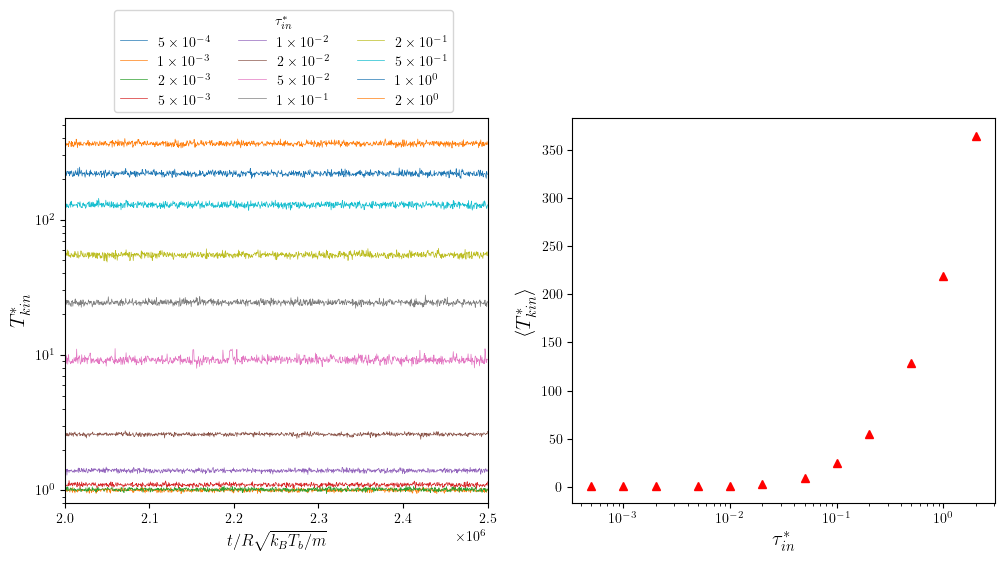

In [5]:
# Plot temperature vs time

nr_list = np.arange(37, 49)
tau_list = ["5e-4", "1e-3", "2e-3", "5e-3", "1e-2", "2e-2", "5e-2", "1e-1", "2e-1", "5e-1", "1e0", "2e0"]
frame_list = [2000]
dt = [5e-5] + [5e-4]*(len(nr_list) - 1)

eq_steps = 1e7
interval = 10

fig1, ax1 = plt.subplots(1, 2, figsize = (12, 5))
for i in range(len(nr_list)):
    fpath = os.path.join(dirpath, "Data{nr}".format(nr = nr_list[i]), "temp.dat")

    [[step, T], _] = readData(fpath, 1)
    time = [(j - eq_steps)*dt[i] for j in step]

    avgT = sum(T)/len(T)
    print("nr = ", nr_list[i], ", avg. T = ", avgT)

    ax1[0].semilogy(time[0::interval], T[0::interval], lw = 0.5, label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    ax1[1].semilogx(liteval(tau_list[i]), avgT, "r^")
    
    # for j in frame_list:
    #     if(j < len(time)):
    #         ax1[0].plot(time[j], T[j], "ro", ms = 6)
        
ax1[0].set_xlim((2.0e6, 2.5e6))

ax1[0].set_ylim(bottom = 0.8)
ax1[0].set_xlabel(r"$t/R \sqrt{k_BT_b/m}$", fontsize = 12)
ax1[0].set_ylabel(r"$T_{kin}^*$", fontsize = 15)
ax1[0].legend(title = r"$\tau_{in}^*$", ncols = 3, bbox_to_anchor=(0.1, 1.0))
# ax1[0].set_title(r"$F_d^* = 90$", loc = "left")

# ax1[1].set_ylim(ylim = (0.9, 1.5))
ax1[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax1[1].set_ylabel(r"$\langle T_{kin}^* \rangle$", fontsize = 15)

# fig1.savefig(os.path.join(figpath, "temp_time_evolve_Fd90.png"), dpi = 500, bbox_inches = "tight")

10000 364.15666269999997 102.32164462839155

n_blk =  [2, 4, 5, 8, 10, 16, 20, 25, 40, 50, 80, 100, 125, 200, 250, 400, 500, 625, 1000, 1250, 2000, 2500, 5000] 
tau_blk =  [5000, 2500, 2000, 1250, 1000, 625, 500, 400, 250, 200, 125, 100, 80, 50, 40, 25, 20, 16, 10, 8, 5, 4, 2]

SEM = 5.074496774041497 7.168166300533283


Text(0, 0.5, '$\\sigma^2 (\\langle\\phi\\rangle_{blk})$')

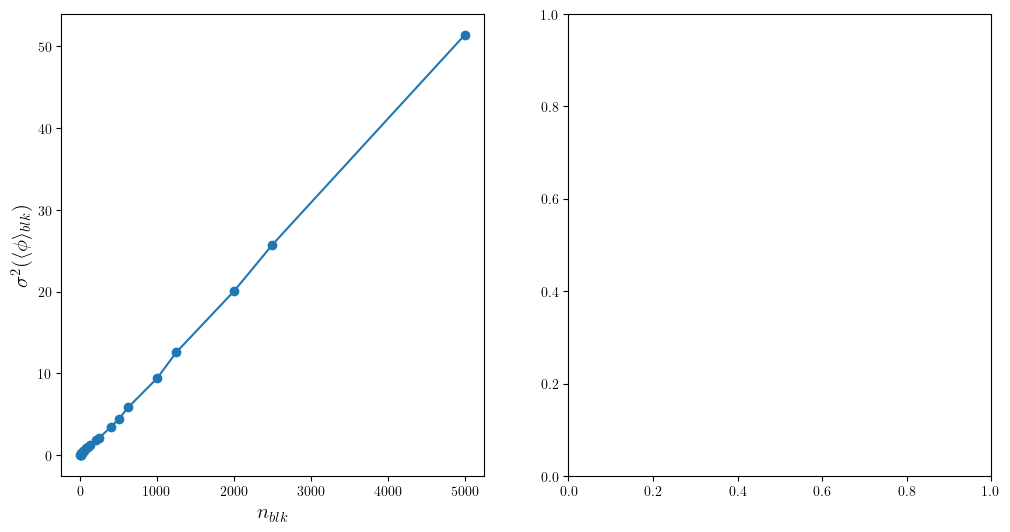

In [16]:
# Compute Standard Error of Mean (SEM) for a data set

fpath = os.path.join(dirpath, "Data48", "temp.dat")
[[step, temp], _] = readData(fpath, 1)
temp = temp[40001:]

tau_run = len(temp)
run_avg = sum(temp)/tau_run
sample_var = sum([(i - run_avg)**2 for i in temp])
sample_var /= (tau_run - 1)

print(tau_run, run_avg, sample_var)

n_blk = []
tau_blk = []

for i in range(2, 5001, 1):
    if(tau_run%i == 0):
        n_blk.append(i)
        tau_blk.append(int(tau_run/i))

tau_blk_inv = [(1/i) for i in tau_blk]
        
print("\nn_blk = ", n_blk, "\ntau_blk = ", tau_blk)

blk_var = []
s = []
for i in range(len(n_blk)):
    blk_avg = np.zeros(n_blk[i])

    for blk in range(n_blk[i]):
        data = temp[int(blk*tau_blk[i]):int((blk+1)*tau_blk[i])]
        blk_avg[blk] = sum(data)/len(data)

    total = 0
    for blk in range(n_blk[i]):
        total += (blk_avg[blk] - run_avg)**2

    blk_var.append(total/(n_blk[i]-1))
    s.append(blk_var[i]*tau_blk[i]/sample_var)
    
pos = len(blk_var)-1
print("\nSEM =", m.sqrt(blk_var[pos-1]), m.sqrt(blk_var[pos]))

fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (12, 6)) 
ax1.plot(n_blk, blk_var, "o-")
ax1.set_xlabel(r"$n_{blk}$", fontsize = 15)
ax1.set_ylabel(r"$\sigma^2 (\langle\phi\rangle_{blk})$", fontsize = 15)
# ax1.set_ylim(top = 0.001)

# ax2.plot(tau_blk, s, "o-")
# ax2.set_xlabel(r"$\tau_{blk}$", fontsize = 15)
# ax2.set_ylabel(r"$s(\tau_{blk})$", fontsize = 15)

In [ ]:
# Compute thermal velocities by subtracting centre-of-mass velocity for each particle type

fpath = os.path.join(dirpath, "Data{nr}".format(nr = 48), "velocities_frame49380.dat")

[data,_] = readData(fpath, 1)

id = data[0]
type = data[1]
rx = data[2]
ry = data[3]
vx = data[4]
vy = data[5]

N = len(id)
print(N)

print(max(vx), min(vx))
print(max(vy), min(vy))

vCom = [[0.0, 0.0], [0.0, 0.0]]
ctr = [[0,0], [0,0]]

for i in range(len(id)):
    ptype = type[i] - 1

    vCom[ptype][0] += vx[i]
    vCom[ptype][1] += vy[i]
    ctr[ptype][0] += 1
    ctr[ptype][1] += 1

for i in range(2):
    for j in range(2):
        vCom[i][j] /= ctr[i][j]

print(vCom)
print(ctr)
print(vCom[0][0] + vCom[1][0], vCom[0][1] + vCom[1][1])

vxth = np.zeros(len(id))
vyth = np.zeros(len(id))

for i in range(len(id)):
    ptype = type[i] - 1
    vxth[i] = vx[i] - vCom[ptype][0]
    vyth[i] = vy[i] - vCom[ptype][1]

In [ ]:
# Calculate the temperature corresponding to the kinetic and thermal velocities

ek = 0.0
ekth = 0.0

for i in range(len(vx)):
    ek += (vx[i]**2 + vy[i]**2)
    ekth += (vxth[i]**2 + vyth[i]**2)

TempKin = round(ek/(2*N), 3)
TempTh = round(ekth/(2*N), 3)
print(TempKin, TempTh)

In [ ]:
# Compute thermal velocities by subtracting centre-of-mass velocity for the system as a whole

fpath = os.path.join(dirpath, "Data{nr}".format(nr = 43), "velocities_frame49431.dat")

[data,_] = readData(fpath, 1)

id = data[0]
type = data[1]
rx = data[2]
ry = data[3]
vx = data[4]
vy = data[5]

N = len(id)
print(N)

print(max(vx), min(vx))
print(max(vy), min(vy))

vCom = [0.0, 0.0]

for i in range(len(id)):
    vCom[0] += vx[i]
    vCom[1] += vy[i]

vCom = [(i/N) for i in vCom]

print(vCom)

vxth = np.zeros(len(id))
vyth = np.zeros(len(id))

for i in range(len(id)):
    vxth[i] = vx[i] - vCom[0]
    vyth[i] = vy[i] - vCom[1]

In [ ]:
# Plot the distribution of velocities

binW = 4.0
min_v = -100
max_v = 100

nBins = int((max_v - min_v)/binW)
Pvx = np.zeros(nBins)
Pvy = np.zeros(nBins)
Pvxth = np.zeros(nBins)
Pvyth = np.zeros(nBins)
Bins = np.linspace(min_v, max_v, nBins)

for i in range(len(id)):
    Pvx[int((vx[i] + max_v)/binW)] += 1
    Pvy[int((vy[i] + max_v)/binW)] += 1
    Pvxth[int((vxth[i] + max_v)/binW)] += 1
    Pvyth[int((vyth[i] + max_v)/binW)] += 1

Pvx = [i/(len(id)*binW) for i in Pvx]
Pvy = [i/(len(id)*binW) for i in Pvy]
Pvxth = [i/(len(id)*binW) for i in Pvxth]
Pvyth = [i/(len(id)*binW) for i in Pvyth]
Pv_boltz = [np.exp(-0.5*v*v)/m.sqrt(2*m.pi) for v in Bins]

sig = 2
Pv_gauss = [np.exp(-0.5*(v/sig)**2)/m.sqrt(2*m.pi*sig**2) for v in Bins]

fig, ax = plt.subplots(2, 1, figsize = (5, 10))
ax[0].plot(Bins, Pvx, "k-", label = r"$v_x$")
ax[0].plot(Bins, Pvy, "ko", label = r"$v_y$")
ax[1].plot(Bins, Pvxth, "r-", label = r"$v_x^{th}$")
ax[1].plot(Bins, Pvyth, "ro", label = r"$v_y^{th}$")
ax[0].plot(Bins, Pv_boltz, "b--", label = "MB dist.")
ax[1].plot(Bins, Pv_boltz, "b--", label = "MB dist.")

ax[0].set(xlim = (min_v, max_v))
ax[0].set_xlabel(r"$v_{\alpha}^{kin}$", fontsize = 12)
ax[0].set_ylabel(r"$P(v_{\alpha}^{kin})$", fontsize = 12)
ax[0].legend(fontsize = 12)

ax[1].set(xlim = (min_v, max_v))
ax[1].set_xlabel(r"$v_{\alpha}^{th}$", fontsize = 12)
ax[1].set_ylabel(r"$P(v_{\alpha}^{th})$", fontsize = 12)
ax[1].legend(fontsize = 12)

print(Bins)

# fig.savefig(os.path.join(figpath, "nr48_gamma_2e-1_vel_dist.png"), dpi = 600, bbox_inches = "tight")

In [ ]:
# Thermal plots

Lx = 150
Ly = 30
ms = 2.4

cmap1 = mpl.colormaps['rainbow']

def return_color(val, max_val):
    color = cmap1(val/max_val)
    return(color)

T_kin = [0.5*(vx[i]*vx[i] + vy[i]*vy[i]) for i in range(len(id))]
T_th = [0.5*(vxth[i]*vxth[i] + vyth[i]*vyth[i]) for i in range(len(id))]
max_T_kin = max(T_kin)
max_T_th = max(T_th)
print(max_T_kin, max_T_th)

fig, ax = plt.subplots(2, 1, figsize = (10, 4))

for i in range(len(id)):
    ax[0].plot(rx[i], ry[i], "o", color = return_color(T_kin[i], max_T_kin), ms = ms)
    ax[1].plot(rx[i], ry[i], "o", color = return_color(T_th[i], max_T_th), ms = ms)
    
for i in range(len(ax)):
    ax[i].set(xlim = (0, Lx), ylim = (0, Ly))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

ax[0].set_ylabel(r"$T^*_{kin} = {val}$".format(kin = "{kin}", val = TempKin), fontsize = 14)
ax[1].set_ylabel(r"$T^*_{th} = {val}$".format(th = "{th}", val = TempTh), fontsize = 14)

clb = mpl.cm.ScalarMappable(norm = mpl.colors.Normalize(0, max_T_kin), cmap = "rainbow")
cbar = fig.colorbar(clb, ax = ax[:], location = "right", shrink = 1.0, aspect = 20, pad = 0.02, fraction = 0.08)
cbar.set_label(label = r"$\tau^*$", fontsize = 15)

fig.savefig(os.path.join(figpath, "nr48_gamma_2e-1_therm_plot.png"), dpi = 500, bbox_inches = "tight")

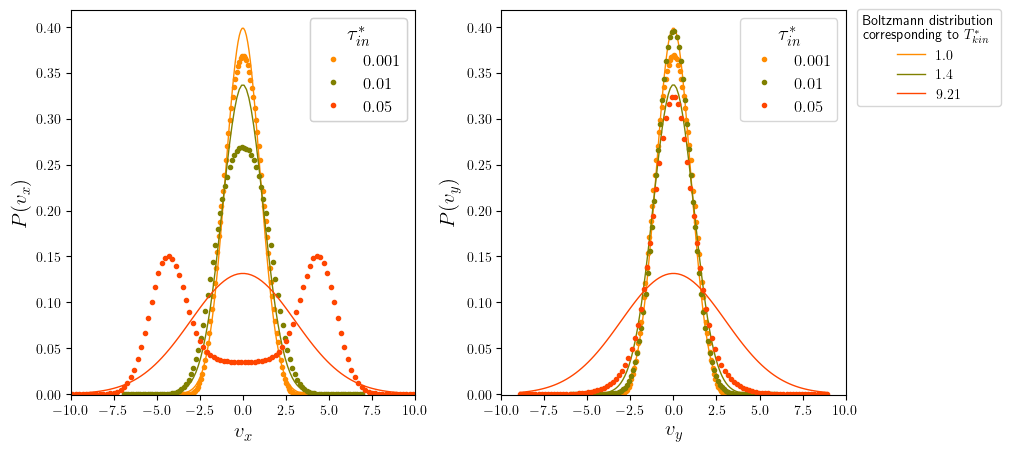

In [123]:
# Plot the time-averaged velocity distribution

nr_list = [38, 41, 43, 47, 48]

fpath = os.path.join(dirpath, "avgThermo.dat")
[[nr, tau, order, temp], _] = readData(fpath)

tau_list = []
Tkin = []

for i in range(len(nr_list)):
    index = nr.index(nr_list[i])
    tau_list.append(tau[index])
    Tkin.append(round(temp[index], 2))

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ms = 3
lw = 1
points = [[], []]
lines = [[], []]

for i in range(0, 3):

    fpath = os.path.join(dirpath, "Data{nr}".format(nr = nr_list[i]), "velocityDist.dat")
    [[bin, Pvx, Pvy], fields] = readData(fpath, 1)
    
    nBins = len(bin)
    vxmax = fields[2]
    vymax = fields[4]
    vxbinW = fields[6]
    vybinW = fields[8]
    
    vx = [(-vxmax + vxbinW * (i + 0.5)) for i in range(nBins)]
    vy = [(-vymax + vybinW * (i + 0.5)) for i in range(nBins)]

    Pvx_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vx]
    Pvy_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vy]

    line1, = ax[0].plot(vx, Pvx_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    line2, = ax[1].plot(vy, Pvy_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    lines[0].append(line1)
    lines[1].append(line2)
    
    point1, = ax[0].plot(vx, Pvx, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = tau_list[i]))
    point2, = ax[1].plot(vy, Pvy, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = tau_list[i]))
    points[0].append(point1)
    points[1].append(point2)

ax[0].set_xlabel(r"$v_x$", fontsize = 15)
ax[0].set_ylabel(r"$P(v_x)$", fontsize = 15)
leg1 = ax[0].legend(handles = points[0], title = r"$\tau_{in}^*$", fontsize = 12)
leg1.get_title().set_fontsize("15")
leg1A = plt.legend(handles = lines[0], bbox_to_anchor = (1, 0))
ax[0].add_artist(leg1)

ax[1].set_xlabel(r"$v_y$", fontsize = 15)
ax[1].set_ylabel(r"$P(v_y)$", fontsize = 15)
leg2 = ax[1].legend(handles = points[1], title = r"$\tau_{in}^*$", fontsize = 12)
leg2.get_title().set_fontsize("15")
leg2A = plt.legend(handles = lines[1], bbox_to_anchor = (1.47, 1.02), title = "Boltzmann distribution \ncorresponding to $T_{kin}^*$")
ax[1].add_artist(leg2)

ax[0].set(xlim = (-10, 10))
ax[1].set(xlim = (-10, 10))
ax[0].set_ylim(bottom = -1e-3)
ax[1].set_ylim(bottom = -1e-3)

plt.subplots_adjust(wspace = 0.25)

# fig.savefig(os.path.join(figpath, "velocityDist_Pe90_1.png"), dpi = 500, bbox_inches = "tight")

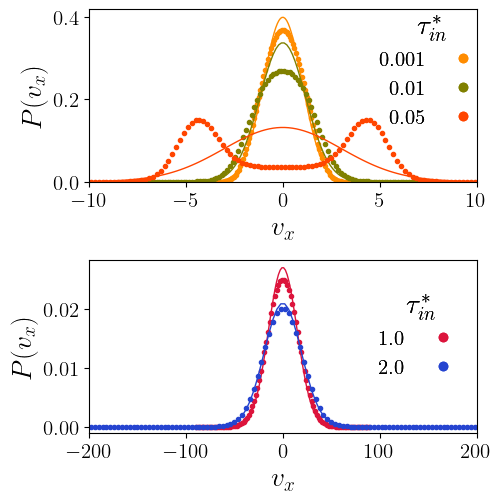

In [84]:
# Plot the time-averaged velocity distribution

nr_list = [38, 41, 43, 47, 48]

fpath = os.path.join(dirpath, "avgThermo.dat")
[[nr, tau, order, temp], _] = readData(fpath)

tau_list = []
Tkin = []

for i in range(len(nr_list)):
    index = nr.index(nr_list[i])
    tau_list.append(tau[index])
    Tkin.append(round(temp[index], 2))

fig, ax = plt.subplots(2, 1, figsize = (5, 5.5))
ms = 3
lw = 1

points = []
lines = []
for i in range(0, 3):
    
    fpath = os.path.join(dirpath, "Data{nr}".format(nr = nr_list[i]), "velocityDist.dat")
    [[bin, Pvx, Pvy], fields] = readData(fpath, 1)
    
    nBins = len(bin)
    vxmax = fields[2]
    vxbinW = fields[6]
    
    vx = [(-vxmax + vxbinW * (i + 0.5)) for i in range(nBins)]
    Pvx_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vx]

    line1, = ax[0].plot(vx, Pvx_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    lines.append(line1)
    
    point1, = ax[0].plot(vx, Pvx, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = tau_list[i]))
    points.append(point1)

ax[0].set_xlabel(r"$v_x$", fontsize = 20)
ax[0].set_ylabel(r"$P(v_x)$", fontsize = 20)
leg1 = ax[0].legend(handles = points, title = r"$\tau_{in}^*$", markerscale = 2, ncols = 1, frameon = False, fontsize = 15, 
                    bbox_to_anchor = (0.7, 0.21), markerfirst = False)
leg1.get_title().set_fontsize("20")
leg1A = plt.legend(handles = lines, bbox_to_anchor = (1, 0))
ax[0].add_artist(leg1)
ax[0].tick_params(axis='both', which='major', labelsize = 15)

points = []
for i in range(3, 5):
    
    fpath = os.path.join(dirpath, "Data{nr}".format(nr = nr_list[i]), "velocityDist.dat")
    [[bin, Pvx, Pvy], fields] = readData(fpath, 1)
    
    nBins = len(bin)
    vxmax = fields[2]
    vxbinW = fields[6]
    
    vx = [(-vxmax + vxbinW * (i + 0.5)) for i in range(nBins)]
    Pvx_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vx]

    line1, = ax[1].plot(vx, Pvx_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    lines.append(line1)
    
    point1, = ax[1].plot(vx, Pvx, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = tau_list[i]))
    points.append(point1)

ax[1].set_xlabel(r"$v_x$", fontsize = 20)
ax[1].set_ylabel(r"$P(v_x)$", fontsize = 20)
leg2 = ax[1].legend(handles = points, title = r"$\tau_{in}^*$", markerscale = 2, ncols = 1, frameon = False, fontsize = 15, 
                    bbox_to_anchor = (0.7, 0.21), markerfirst = False)
leg2.get_title().set_fontsize("20")
# leg2A = plt.legend(handles = lines, bbox_to_anchor = (1.47, 2.3), title = "Boltzmann distribution \ncorresponding to $T_{kin}^*$", 
#                    fontsize = 15)
# leg2A.get_title().set_fontsize("15")
ax[1].add_artist(leg2)
ax[1].tick_params(axis='both', which='major', labelsize = 15)

ax[0].set(xlim = (-10, 10))
ax[1].set(xlim = (-200, 200))
ax[0].set_ylim(bottom = -1e-3)
ax[1].set_ylim(bottom = -1e-3)

plt.subplots_adjust(hspace = 0.45, wspace = 0.3)

# fig.savefig(os.path.join(figpath, "velocityDist_Pe90_both.png"), dpi = 500, bbox_inches = "tight")